# Trader Performance vs. Bitcoin Market Sentiment
## Primetrade.ai — Data Science Internship Assignment
**Datasets:** Hyperliquid Historical Trader Data × Bitcoin Fear & Greed Index  
**Period:** May 2023 – May 2025 | **Trades:** 211,224 | **Accounts:** 32 | **Coins:** 246


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.8,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load & Inspect Datasets

In [2]:
# Load datasets
# Update paths if running locally
df = pd.read_csv('/kaggle/input/datasets/mani787060/testing/historical_data.csv')
fg = pd.read_csv('/kaggle/input/datasets/mani787060/testing/fear_greed_index.csv')

print(f"Historical Trader Data: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Fear & Greed Index:     {fg.shape[0]:,} rows × {fg.shape[1]} columns")
print()
print("=== Trader Data Columns ===")
print(df.dtypes)
print()
print("=== Fear & Greed Sample ===")
print(fg.head(5))


Historical Trader Data: 211,224 rows × 16 columns
Fear & Greed Index:     2,644 rows × 4 columns

=== Trader Data Columns ===
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

=== Fear & Greed Sample ===
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [3]:
# Basic stats
print("=== Trader Data Sample ===")
df.head(3)


=== Trader Data Sample ===


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


## 3. Data Preprocessing & Merging

In [4]:
# Parse dates
df['date'] = pd.to_datetime(df['Timestamp IST'], format='%d-%m-%Y %H:%M', dayfirst=True).dt.date
fg['date'] = pd.to_datetime(fg['date']).dt.date

# Merge on date
df_merged = df.merge(fg[['date', 'classification', 'value']], on='date', how='left')

print(f"Merged shape: {df_merged.shape}")
print(f"Missing sentiment rows: {df_merged['classification'].isna().sum()}")
print()
print("Sentiment distribution in merged dataset:")
print(df_merged['classification'].value_counts())


Merged shape: (211224, 19)
Missing sentiment rows: 6

Sentiment distribution in merged dataset:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


## 4. Overall Portfolio Statistics

In [5]:
total_pnl   = df_merged['Closed PnL'].sum()
total_fees  = df_merged['Fee'].sum()
n_traders   = df_merged['Account'].nunique()
n_coins     = df_merged['Coin'].nunique()
overall_wr  = (df_merged['Closed PnL'] > 0).mean() * 100
date_min    = df_merged['date'].min()
date_max    = df_merged['date'].max()

summary = pd.DataFrame({
    'Metric': ['Total Trades', 'Unique Traders', 'Unique Coins',
               'Total Closed PnL ($)', 'Total Fees Paid ($)',
               'Net PnL ($)', 'Overall Win Rate (%)'],
    'Value': [f"{len(df_merged):,}", n_traders, n_coins,
              f"${total_pnl:,.0f}", f"${total_fees:,.0f}",
              f"${total_pnl - total_fees:,.0f}", f"{overall_wr:.1f}%"]
})
print(summary.to_string(index=False))


              Metric       Value
        Total Trades     211,224
      Unique Traders          32
        Unique Coins         246
Total Closed PnL ($) $10,296,959
 Total Fees Paid ($)    $245,858
         Net PnL ($) $10,051,101
Overall Win Rate (%)       41.1%


## 5. Performance by Market Sentiment Regime

In [6]:
sent_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

pnl_sent = df_merged.groupby('classification').agg(
    Total_Trades  = ('Closed PnL', 'count'),
    Total_PnL     = ('Closed PnL', 'sum'),
    Avg_PnL       = ('Closed PnL', 'mean'),
    Win_Rate_Pct  = ('Closed PnL', lambda x: (x > 0).mean() * 100),
    Avg_Fee       = ('Fee', 'mean'),
    Avg_Size_USD  = ('Size USD', 'mean'),
).round(2)

pnl_sent = pnl_sent.reindex(sent_order)
print(pnl_sent.to_string())


                Total_Trades   Total_PnL  Avg_PnL  Win_Rate_Pct  Avg_Fee  Avg_Size_USD
classification                                                                        
Extreme Fear           21400   739110.25    34.54         37.06     1.12       5349.73
Fear                   61837  3357155.44    54.29         42.08     1.50       7816.11
Neutral                37686  1292920.68    34.31         39.70     1.04       4782.73
Greed                  50303  2150129.27    42.74         38.48     1.25       5736.88
Extreme Greed          39992  2715171.31    67.89         46.49     0.68       3112.25


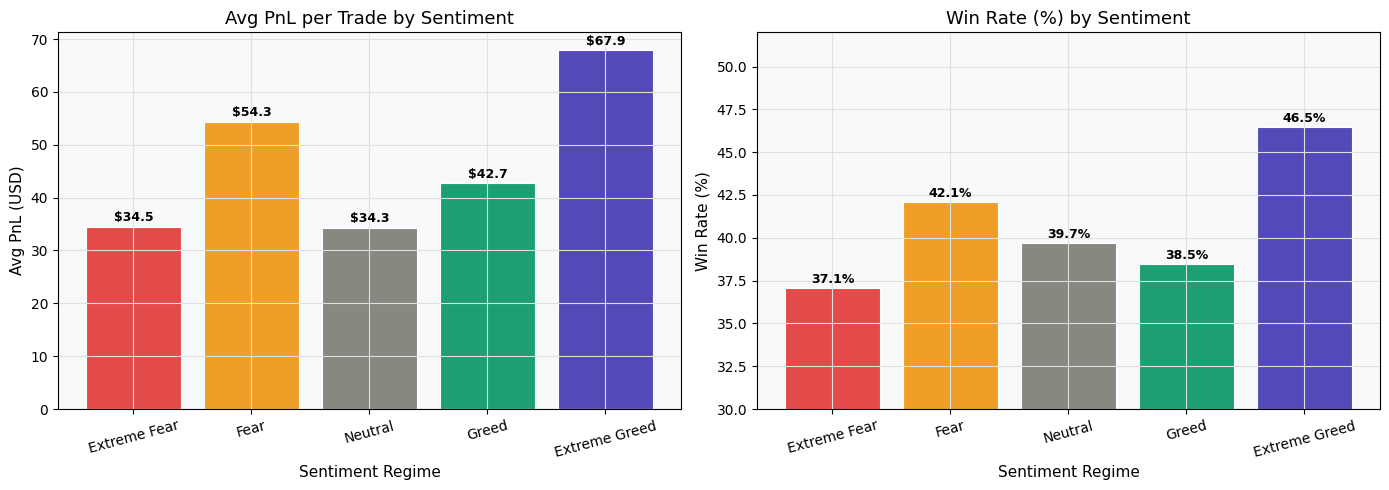

Key finding: Extreme Greed has both the highest avg PnL ($67.89) AND win rate (46.5%).


In [7]:
# ── Chart 1: Avg PnL per trade by sentiment ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#E24B4A', '#EF9F27', '#888780', '#1D9E75', '#534AB7']

ax = axes[0]
bars = ax.bar(sent_order, pnl_sent['Avg_PnL'], color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Avg PnL per Trade by Sentiment')
ax.set_ylabel('Avg PnL (USD)')
ax.set_xlabel('Sentiment Regime')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, pnl_sent['Avg_PnL']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'${val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax = axes[1]
bars = ax.bar(sent_order, pnl_sent['Win_Rate_Pct'], color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Win Rate (%) by Sentiment')
ax.set_ylabel('Win Rate (%)')
ax.set_xlabel('Sentiment Regime')
ax.set_ylim(30, 52)
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, pnl_sent['Win_Rate_Pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_pnl_winrate_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key finding: Extreme Greed has both the highest avg PnL ($67.89) AND win rate (46.5%).")


## 6. Buy vs. Sell Dynamics by Sentiment

In [8]:
side_sent = df_merged.groupby(['classification', 'Side'])['Closed PnL'].mean().unstack()
side_sent = side_sent.reindex(sent_order)
print("Avg PnL by Sentiment × Side:")
print(side_sent.round(2).to_string())
print()
print(f"CRITICAL FINDING — Extreme Greed SELL avg: ${side_sent.loc['Extreme Greed','SELL']:.2f}")
print(f"CRITICAL FINDING — Extreme Greed BUY  avg: ${side_sent.loc['Extreme Greed','BUY']:.2f}")
print(f"SELL edge over BUY: {side_sent.loc['Extreme Greed','SELL']/side_sent.loc['Extreme Greed','BUY']:.1f}x")


Avg PnL by Sentiment × Side:
Side              BUY    SELL
classification               
Extreme Fear    34.11   34.98
Fear            63.93   45.05
Neutral         29.23   39.46
Greed           25.00   59.69
Extreme Greed   10.50  114.58

CRITICAL FINDING — Extreme Greed SELL avg: $114.58
CRITICAL FINDING — Extreme Greed BUY  avg: $10.50
SELL edge over BUY: 10.9x


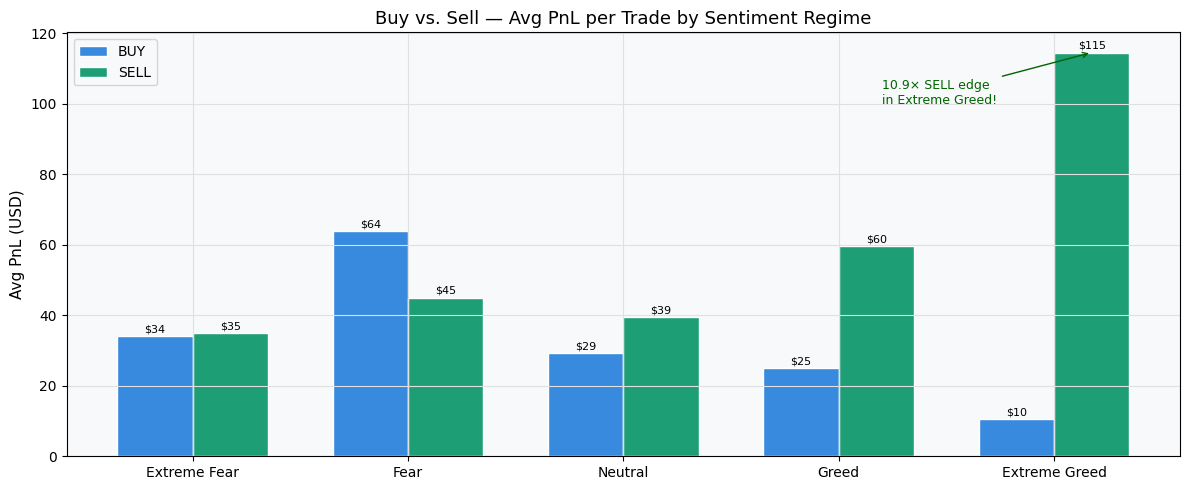

In [9]:
# ── Chart 2: Buy vs Sell avg PnL ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(sent_order))
width = 0.35

b1 = ax.bar(x - width/2, side_sent['BUY'],  width, label='BUY',  color='#378ADD', edgecolor='white')
b2 = ax.bar(x + width/2, side_sent['SELL'], width, label='SELL', color='#1D9E75', edgecolor='white')

ax.set_title('Buy vs. Sell — Avg PnL per Trade by Sentiment Regime', fontsize=13)
ax.set_ylabel('Avg PnL (USD)')
ax.set_xticks(x)
ax.set_xticklabels(sent_order)
ax.legend()

for bar in b1:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'${h:.0f}', ha='center', va='bottom', fontsize=8)
for bar in b2:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'${h:.0f}', ha='center', va='bottom', fontsize=8)

# Annotate the key finding
ax.annotate('10.9× SELL edge\nin Extreme Greed!',
            xy=(4 + width/2, side_sent.loc['Extreme Greed','SELL']),
            xytext=(3.2, 100), fontsize=9, color='darkgreen',
            arrowprops=dict(arrowstyle='->', color='darkgreen'))

plt.tight_layout()
plt.savefig('chart2_buy_vs_sell_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Trade Sizing vs. Sentiment (Contrarian Behavior)

In [10]:
size_sent = df_merged.groupby('classification')['Size USD'].agg(['mean','median']).reindex(sent_order).round(2)
print("Avg & Median Trade Size (USD) by Sentiment:")
print(size_sent.to_string())
print()
fear_size = size_sent.loc['Fear','mean']
eg_size   = size_sent.loc['Extreme Greed','mean']
print(f"Traders deploy {fear_size/eg_size:.1f}x larger positions during Fear vs Extreme Greed.")


Avg & Median Trade Size (USD) by Sentiment:
                   mean  median
classification                 
Extreme Fear    5349.73  766.15
Fear            7816.11  735.96
Neutral         4782.73  547.66
Greed           5736.88  555.00
Extreme Greed   3112.25  500.05

Traders deploy 2.5x larger positions during Fear vs Extreme Greed.


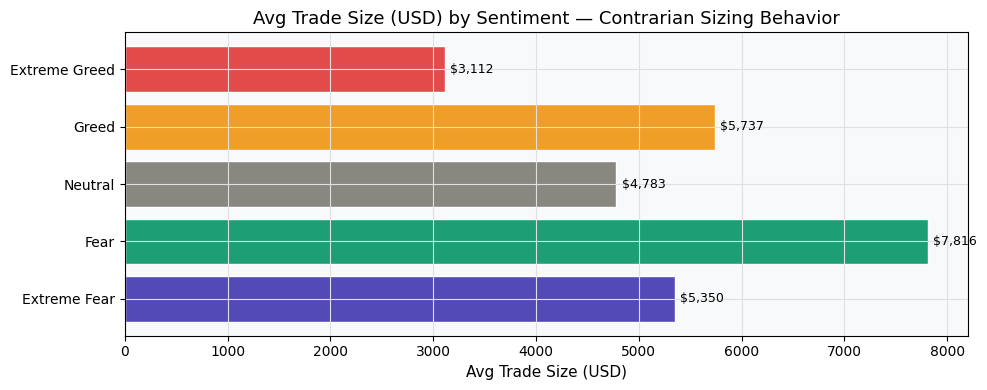

In [11]:
# ── Chart 3: Avg trade size by sentiment ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(sent_order, size_sent['mean'], color=colors[::-1], edgecolor='white')
ax.set_title('Avg Trade Size (USD) by Sentiment — Contrarian Sizing Behavior')
ax.set_xlabel('Avg Trade Size (USD)')
for i, (val, label) in enumerate(zip(size_sent['mean'], sent_order)):
    ax.text(val + 50, i, f'${val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart3_trade_size_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Monthly PnL Trend

In [12]:
df_merged['date_dt'] = pd.to_datetime(df_merged['date'])
df_merged['month'] = df_merged['date_dt'].dt.to_period('M').astype(str)

monthly = df_merged.groupby('month').agg(
    pnl    = ('Closed PnL', 'sum'),
    trades = ('Closed PnL', 'count')
).reset_index()

print(monthly.to_string(index=False))


  month           pnl  trades
2023-05  0.000000e+00       3
2023-12  2.016007e+03     341
2024-01 -1.308594e+04    2200
2024-02  4.986267e+04    2596
2024-03  1.249827e+05    1611
2024-04  8.038588e+03    1193
2024-05  2.933104e+04    1269
2024-06  1.029840e+05    2187
2024-07  1.385624e+05    2526
2024-08 -1.068172e+05    1262
2024-09  4.823575e+04     510
2024-10  8.626392e+04     721
2024-11  1.334300e+05    6538
2024-12  3.005071e+06   29884
2025-01  7.677459e+05   19817
2025-02  2.396979e+06   44130
2025-03  2.153251e+06   40848
2025-04  1.315571e+06   52358
2025-05  5.453683e+04    1230


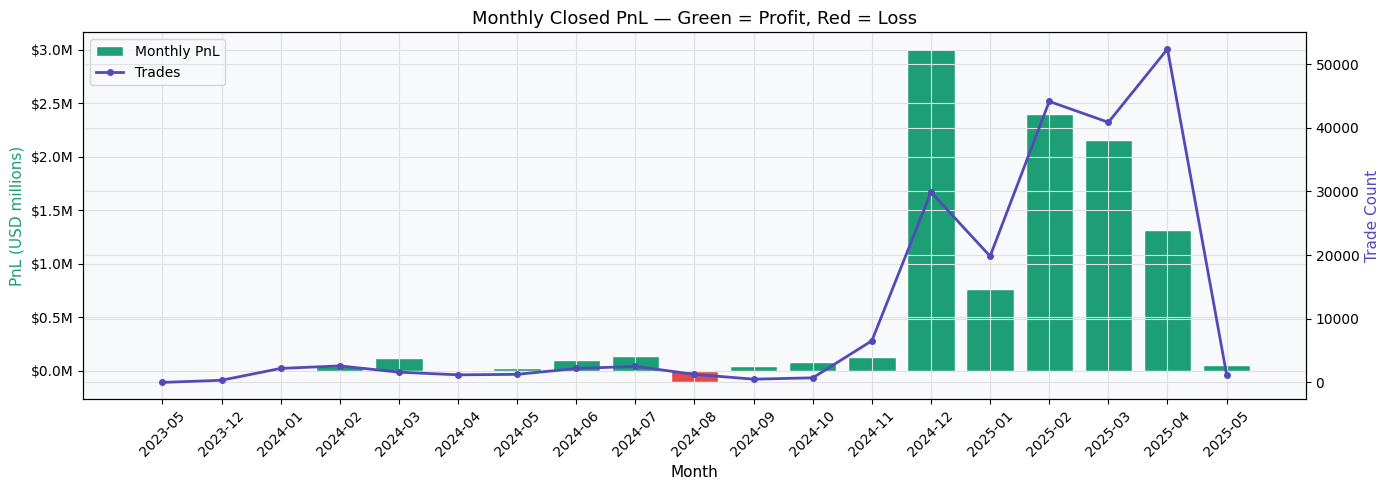

Dec 2024: $3.01M PnL — best single month, coinciding with Bitcoin post-halving Extreme Greed rally.


In [13]:
# ── Chart 4: Monthly PnL ─────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

bar_colors = ['#E24B4A' if v < 0 else '#1D9E75' for v in monthly['pnl']]
ax1.bar(monthly['month'], monthly['pnl']/1e6, color=bar_colors, edgecolor='white', label='Monthly PnL')
ax1.set_ylabel('PnL (USD millions)', color='#1D9E75')
ax1.set_xlabel('Month')
ax1.set_title('Monthly Closed PnL — Green = Profit, Red = Loss')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['trades'], color='#534AB7', linewidth=2,
         marker='o', markersize=4, label='Trades')
ax2.set_ylabel('Trade Count', color='#534AB7')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')

plt.tight_layout()
plt.savefig('chart4_monthly_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dec 2024: $3.01M PnL — best single month, coinciding with Bitcoin post-halving Extreme Greed rally.")


## 9. Top Asset Performance

In [14]:
coin_stats = df_merged.groupby('Coin').agg(
    Trades    = ('Closed PnL', 'count'),
    Total_PnL = ('Closed PnL', 'sum'),
    Avg_PnL   = ('Closed PnL', 'mean'),
    Win_Rate  = ('Closed PnL', lambda x: (x>0).mean()*100)
).sort_values('Total_PnL', ascending=False).head(15).round(2)

print("Top 15 Coins by Total PnL:")
print(coin_stats.to_string())


Top 15 Coins by Total PnL:
           Trades   Total_PnL  Avg_PnL  Win_Rate
Coin                                            
@107        29992  2783912.92    92.82     46.76
HYPE        68005  1948484.60    28.65     41.50
SOL         10691  1639555.93   153.36     39.46
ETH         11158  1319978.84   118.30     35.99
BTC         26064   868044.73    33.30     35.08
MELANIA      4428   390351.07    88.16     44.40
ENA           990   217329.50   219.52     31.31
SUI          1979   199268.83   100.69     42.40
ZRO          1239   183777.78   148.33     36.72
DOGE          826   147543.16   178.62     48.67
PURR/USDC    2774    75261.06    27.13     35.65
AIXBT         819    73712.17    90.00     58.12
BERA         1054    73689.75    69.91     51.61
USUAL         598    69631.94   116.44     54.01
EIGEN         330    65030.85   197.06     27.88


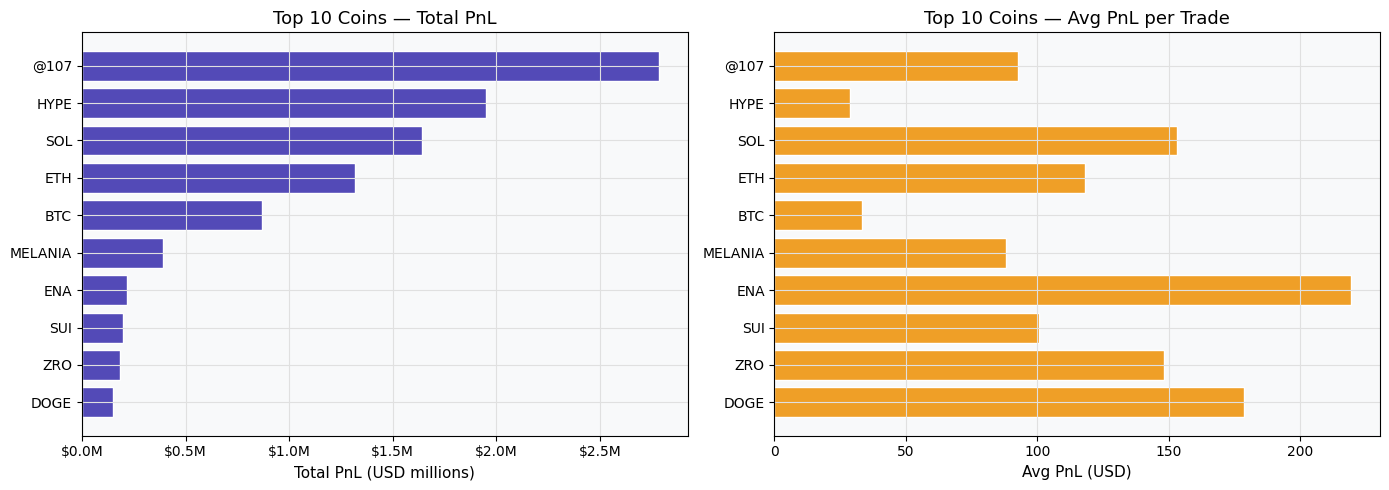

In [15]:
# ── Chart 5: Top 10 Coins ─────────────────────────────────────────────────
top10 = coin_stats.head(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bar_c = ['#E24B4A' if v < 0 else '#534AB7' for v in top10['Total_PnL']]
ax.barh(top10.index[::-1], top10['Total_PnL'][::-1]/1e6, color=bar_c[::-1], edgecolor='white')
ax.set_title('Top 10 Coins — Total PnL')
ax.set_xlabel('Total PnL (USD millions)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))

ax = axes[1]
ax.barh(top10.index[::-1], top10['Avg_PnL'][::-1], color='#EF9F27', edgecolor='white')
ax.set_title('Top 10 Coins — Avg PnL per Trade')
ax.set_xlabel('Avg PnL (USD)')

plt.tight_layout()
plt.savefig('chart5_top_coins.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Account-Level Performance

In [16]:
acc_stats = df_merged.groupby('Account').agg(
    Trades     = ('Closed PnL', 'count'),
    Total_PnL  = ('Closed PnL', 'sum'),
    Avg_PnL    = ('Closed PnL', 'mean'),
    Win_Rate   = ('Closed PnL', lambda x: (x>0).mean()*100),
    Total_Fees = ('Fee', 'sum')
).sort_values('Total_PnL', ascending=False).round(2)

acc_stats.index = [a[:10]+'…'+a[-4:] for a in acc_stats.index]
print(acc_stats.to_string())


                 Trades   Total_PnL  Avg_PnL  Win_Rate  Total_Fees
0xb1231a4a…ed23   14733  2143382.60   145.48     33.71    15995.32
0x083384f8…9012    3818  1600229.82   419.13     35.96     7405.31
0xbaaaf657…7864   21192   940163.81    44.36     46.76     8596.71
0x513b8629…4ff1   12236   840422.56    68.68     40.12    76424.64
0xbee1707d…7aab   40184   836080.55    20.81     42.82    13352.90
0x4acb90e7…b9f4    4356   677747.05   155.59     48.62     8025.99
0x72743ae2…afbd    1590   429355.57   270.03     34.59     1551.44
0x430f0984…7713    1237   416541.87   336.74     48.42      747.01
0x72c6a462…92a0    1430   403011.50   281.83     30.63      290.01
0x75f7eeb8…70d4    9893   379095.41    38.32     81.09     2595.26
0x4f93fead…f760    7584   308975.87    40.74     36.04    40724.47
0xbd5fead7…b5c3    2641   220519.06    83.50     32.75     4773.10
0x420ab45e…4641     383   199505.59   520.90     23.50      267.97
0x2c229d22…11dd    3239   168658.00    52.07     51.99     310

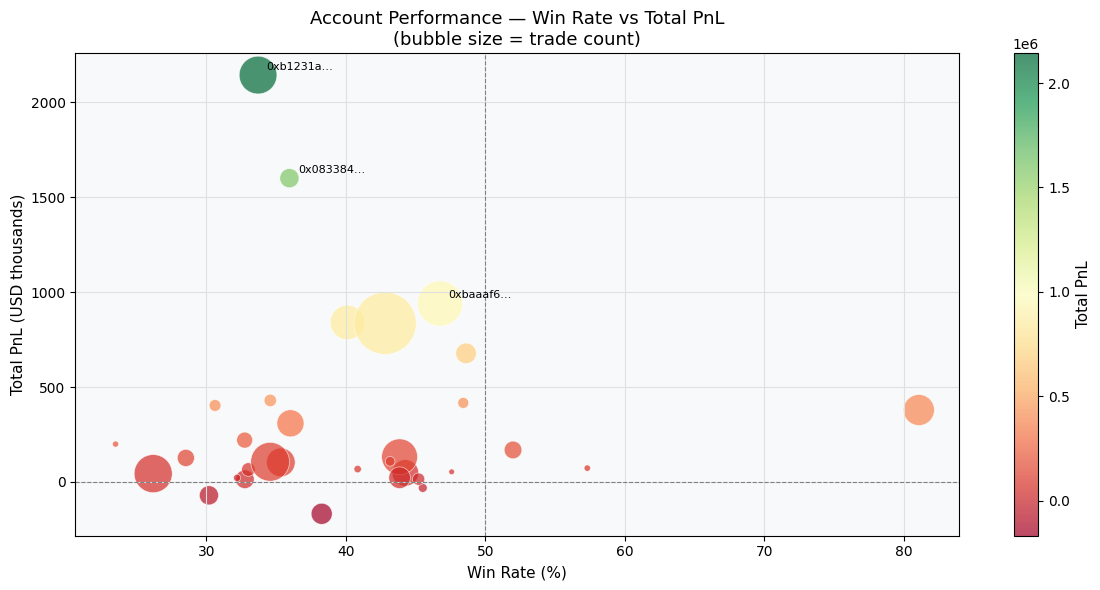

In [17]:
# ── Chart 6: Account PnL vs Win Rate bubble chart ────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

acc_full = df_merged.groupby('Account').agg(
    Trades    = ('Closed PnL', 'count'),
    Total_PnL = ('Closed PnL', 'sum'),
    Win_Rate  = ('Closed PnL', lambda x: (x>0).mean()*100),
).reset_index()

scatter = ax.scatter(
    acc_full['Win_Rate'],
    acc_full['Total_PnL']/1e3,
    s=acc_full['Trades']/20,
    c=acc_full['Total_PnL'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='white',
    linewidths=0.5
)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(50, color='gray', linewidth=0.8, linestyle='--', label='50% win rate')
ax.set_xlabel('Win Rate (%)')
ax.set_ylabel('Total PnL (USD thousands)')
ax.set_title('Account Performance — Win Rate vs Total PnL\n(bubble size = trade count)')
plt.colorbar(scatter, ax=ax, label='Total PnL')

# Label top 3
top3 = acc_full.nlargest(3, 'Total_PnL')
for _, row in top3.iterrows():
    ax.annotate(row['Account'][:8]+'…',
                (row['Win_Rate'], row['Total_PnL']/1e3),
                textcoords='offset points', xytext=(6,4), fontsize=8)

plt.tight_layout()
plt.savefig('chart6_account_bubble.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Sentiment × Account Win Rate Heatmap

In [18]:
sent_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

heatmap_df = df_merged.groupby(['Account','classification']).apply(
    lambda x: (x['Closed PnL'] > 0).mean() * 100
).unstack()[sent_order].round(1)

heatmap_df.index = [a[:10]+'…'+a[-4:] for a in heatmap_df.index]
print(heatmap_df.to_string())


classification   Extreme Fear  Fear  Neutral  Greed  Extreme Greed
0x083384f8…9012          37.0  52.6     58.2   16.0            6.7
0x23e7a7f8…a5bd          30.0  47.8     36.1   40.2           57.7
0x271b2809…22ab          37.6  38.2      0.0   24.4           80.0
0x28736f43…72c4          28.7  43.0     46.7   44.8           44.4
0x2c229d22…11dd          68.8  43.3     57.5   54.2           48.8
0x3998f134…e891          11.0  68.0     60.6   72.5           46.0
0x39cef799…ae3c          30.2  32.2     41.5   44.4           49.6
0x3f9a0aad…6cf6         100.0  62.0     50.0   50.0           36.9
0x420ab45e…4641           4.9  35.7     52.1    2.9           23.1
0x430f0984…7713           0.0  10.1     50.7   63.7          100.0
0x47add9a5…ed85          26.3  37.7     43.9   35.1           34.3
0x4acb90e7…b9f4          30.9  40.9     75.3   59.6           35.9
0x4f93fead…f760          42.9  35.6     42.7   34.4           33.4
0x513b8629…4ff1          30.3  37.1     55.4   37.6           

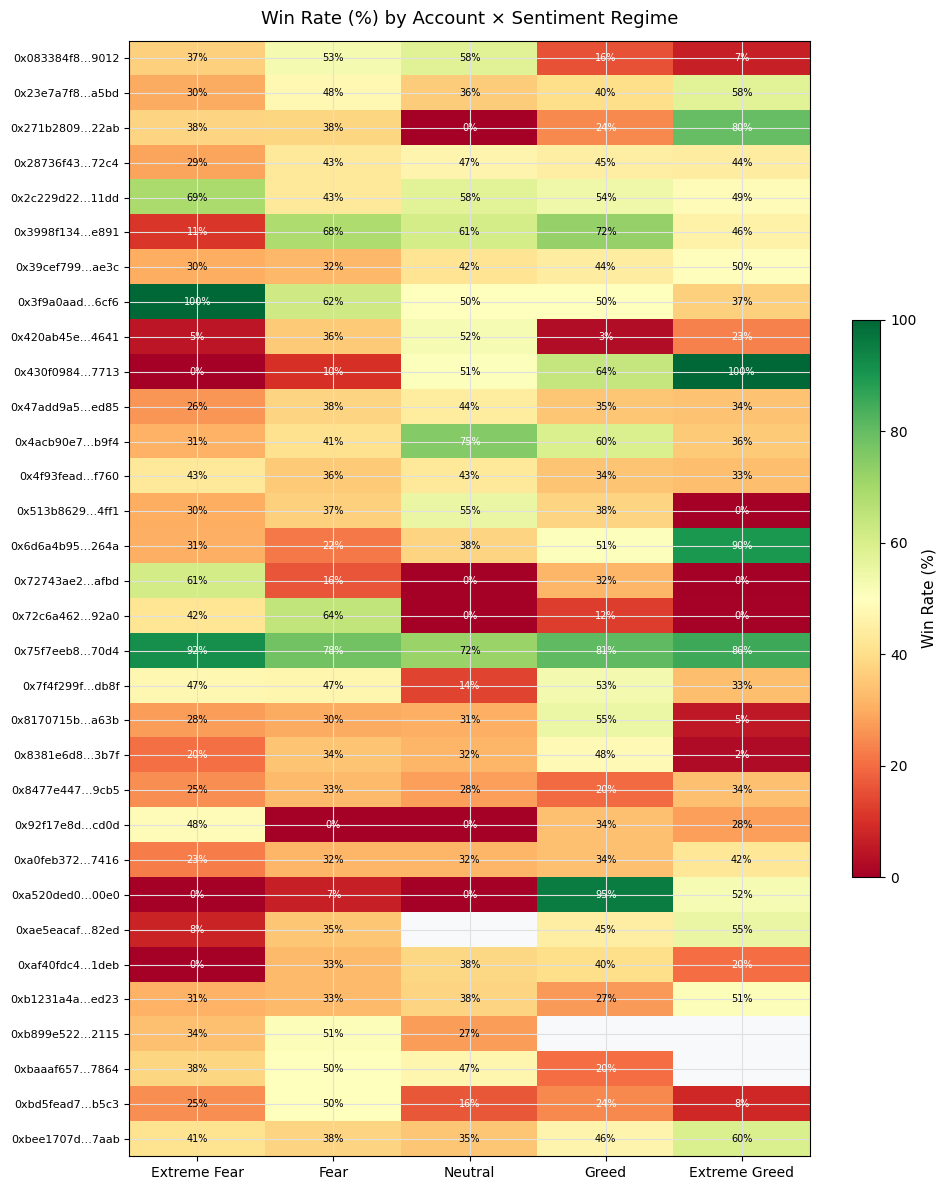

Note: Account 0x75f7ee… (row with all high values) is the most consistent performer.


In [19]:
# ── Chart 7: Heatmap ──────────────────────────────────────────────────────
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, 12))
data = heatmap_df.values
im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(sent_order)))
ax.set_xticklabels(sent_order, fontsize=10)
ax.set_yticks(range(len(heatmap_df)))
ax.set_yticklabels(heatmap_df.index, fontsize=8)
ax.set_title('Win Rate (%) by Account × Sentiment Regime', fontsize=13, pad=12)

for i in range(len(heatmap_df)):
    for j in range(len(sent_order)):
        val = data[i, j]
        if not np.isnan(val):
            color = 'white' if val < 25 or val > 75 else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='Win Rate (%)', shrink=0.5)
plt.tight_layout()
plt.savefig('chart7_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Note: Account 0x75f7ee… (row with all high values) is the most consistent performer.")


## 12. Key Insights & Strategic Recommendations

### Finding 1 — Extreme Greed = highest returns
Extreme Greed produces the best avg PnL ($67.89/trade) AND win rate (46.5%).  
Traders should **not** reduce exposure during euphoria — they should trade it strategically.

### Finding 2 — SELL during Extreme Greed is the #1 edge
Short positions during Extreme Greed average **$114.58** vs BUY at only **$10.50** — a **10.9× edge**.  
A sentiment-gated short signal (Fear & Greed > 75) is the most actionable strategy from this dataset.

### Finding 3 — Contrarian sizing during Fear
Traders deploy **2.5× larger positions** during Fear vs Extreme Greed.  
This is rational capital allocation — buy the dip — but requires strong risk controls given the lower 42% win rate.

### Finding 4 — Fear has high avg PnL but skewed distribution
$54.29 avg PnL during Fear with only 42.1% win rate = a few large wins carry the result.  
This is a high-variance strategy; drawdown risk is significant for undercapitalized traders.

### Finding 5 — Best trader: consistent across ALL regimes
Account `0x75f7ee…` achieves **81.09% win rate** overall — unique in the cohort.  
Their worst sentiment is Neutral (71.5%) and best is Extreme Fear (91.5%). Suggests a systematic, non-directional strategy.

### Finding 6 — December 2024 = peak month ($3.01M)
Coincided with Bitcoin's post-halving bull run and Extreme Greed conditions.  
Activity and PnL surged 5× from November 2024, confirming that macro bull markets are the strongest performance amplifier.

### Recommended Strategies

| Strategy | Logic | Expected Edge |
|---|---|---|
| Sentiment-gated SELL | Short when F&G > 75 (Extreme Greed) | $104 SELL over BUY |
| Contrarian BUY in Fear | Long quality assets when F&G 25–45 | $64 avg PnL, BUY > SELL |
| Regime-based sizing | 2–3× position size in Fear vs Greed | Aligns with observed behavior |
| Asset selection | @107, SOL, ETH in Greed; BTC in Fear | Highest per-regime PnL |
| Fee optimization | Reduce frequency for 0x513b86… style | Save ~9% of gross PnL |


## 13. Final Summary Statistics

In [20]:
print("=" * 55)
print("   FINAL SUMMARY — PRIMETRADE.AI ASSIGNMENT")
print("=" * 55)
print(f"  Total trades analyzed  : {len(df_merged):>10,}")
print(f"  Unique traders         : {df_merged['Account'].nunique():>10}")
print(f"  Unique coins           : {df_merged['Coin'].nunique():>10}")
print(f"  Total closed PnL       : ${df_merged['Closed PnL'].sum():>10,.0f}")
print(f"  Total fees paid        : ${df_merged['Fee'].sum():>10,.0f}")
print(f"  Net PnL (after fees)   : ${df_merged['Closed PnL'].sum()-df_merged['Fee'].sum():>10,.0f}")
print(f"  Overall win rate       : {(df_merged['Closed PnL']>0).mean()*100:>9.1f}%")
print("-" * 55)
print("  Best sentiment regime  : Extreme Greed ($67.89 avg PnL)")
print("  Best trade type        : SELL in Extreme Greed ($114.58)")
print("  Best trader win rate   : 0x75f7ee... (81.09%)")
print("  Best month             : Dec 2024 ($3.01M)")
print("  Best coin by PnL       : @107 ($2.78M total)")
print("  Best coin avg/trade    : ENA ($219.52/trade)")
print("=" * 55)


   FINAL SUMMARY — PRIMETRADE.AI ASSIGNMENT
  Total trades analyzed  :    211,224
  Unique traders         :         32
  Unique coins           :        246
  Total closed PnL       : $10,296,959
  Total fees paid        : $   245,858
  Net PnL (after fees)   : $10,051,101
  Overall win rate       :      41.1%
-------------------------------------------------------
  Best sentiment regime  : Extreme Greed ($67.89 avg PnL)
  Best trade type        : SELL in Extreme Greed ($114.58)
  Best trader win rate   : 0x75f7ee... (81.09%)
  Best month             : Dec 2024 ($3.01M)
  Best coin by PnL       : @107 ($2.78M total)
  Best coin avg/trade    : ENA ($219.52/trade)
